In [1]:
import adios4dolfinx
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

from dolfinx.fem.petsc import LinearProblem
from ufl import sqrt, inner, TestFunction, TrialFunction, dot, grad, CellDiameter, dx
from pathlib import Path
from mpi4py import MPI
from dolfinx import mesh, fem, io, plot
from basix.ufl import element


In [2]:
wind_file = Path("../inverse_AD/wind_data/velocity.bp")
domain = adios4dolfinx.read_mesh(wind_file, MPI.COMM_WORLD)
facet_tags = adios4dolfinx.read_meshtags(wind_file, domain, meshtag_name="facet_tags")


topology, cell_type, geom = plot.vtk_mesh(domain) 
grid = pv.UnstructuredGrid(topology, cell_type, geom)

dom_cell = domain.basix_cell()
V_wind = fem.functionspace(domain, element("Lagrange", dom_cell, 1, shape=(domain.topology.dim,)))

u_true = fem.Function(V_wind)
adios4dolfinx.read_function(wind_file, u_true, name="velocity")

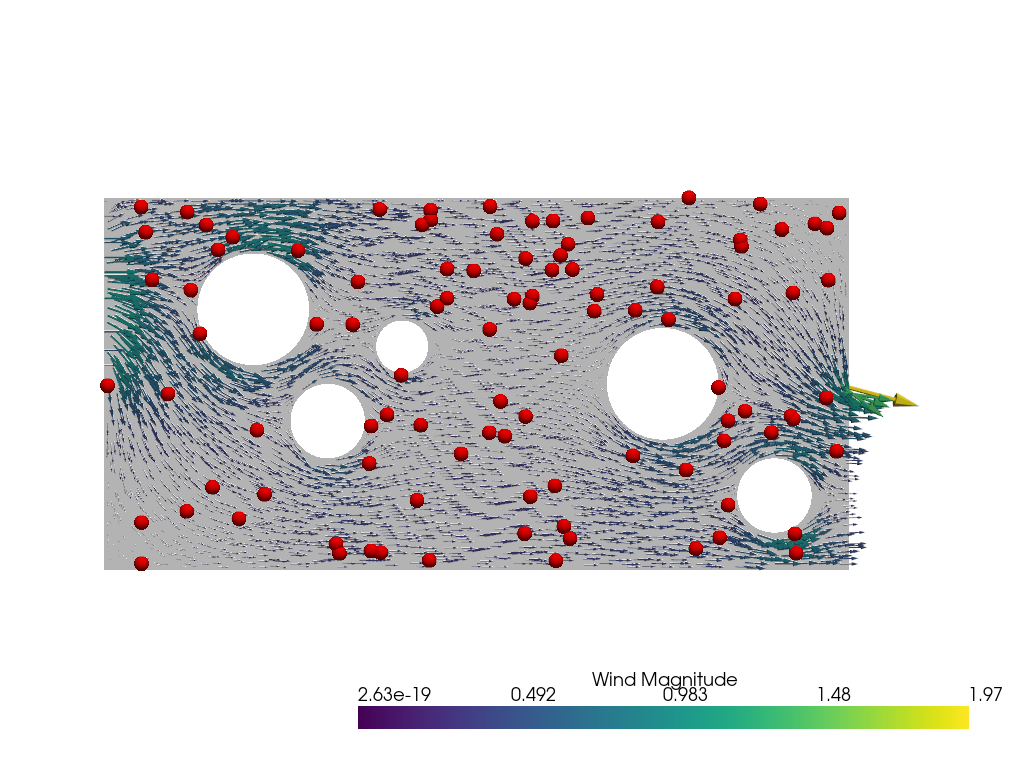

In [14]:
# Wind field in 2D and 3D
wind2d = u_true.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d

# Get random set of wind measurements
p = 100
n = len(wind2d)
rng = np.random.default_rng()
m_ids = rng.choice(np.arange(n+1), p, replace=False)

m = np.zeros_like(wind2d)
m[m_ids] = wind2d[m_ids]
m = m.reshape((-1, ))

# Visualize
measured = pv.PolyData(grid.points[m_ids])
wind_plot_indices = np.arange(0, grid.n_points, 5) # less dense plot
subset = grid.extract_points(wind_plot_indices, include_cells=False)
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.1)

pl = pv.Plotter()
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind Magnitude"})
pl.add_mesh(grid, color='k', opacity=0.3)
pl.add_mesh(measured, color='red', point_size=15, render_points_as_spheres=True) # mark measurements
pl.view_xy()
pl.zoom_camera(1.2)
pl.show()


In [4]:
# Set up known boundary conditions (no slip at obstacles only)
# facet tags hab ich... aber muss ich die jetzt wieder so kompliziert raussuchen, um die boundary conditions zu setzen??

In [5]:
# Set up forward problem

In [6]:
# Set up inverse problem